## 终极消融实验

🚀 史诗级六相消融：线性拟合 vs RMT vs 静态 vs 方法1 vs 方法2(1D) vs 方法5(2D)
[*] 正在计算 Model 0: 直接线性拟合 (Null Hypothesis Baseline)...
[M0: 直接线性拟合] Slope: 2.1031 | Intercept: 33.5112 | MSE: 28.67 | 平均误差: 6.68% | 最大误差: 151.96%
[*] 正在计算 Model 1: 完全随机马尔可夫矩阵 (RMT)...
[*] 正在计算 Model 2: 静态自治系统 (U_c=1.543689)...
[*] 正在计算 Model 3: 渐近截断非自治系统 (Asymptotic Truncation)...
[*] 正在计算 Model 4: U_dyna 绝对边界锚定非自治系统 (1D)... 预计耗时1-2分钟
   -> Model 4 内核演化完成，耗时 329.7 秒
[*] 正在计算 Model 5: U_dyna 2D 高阶绝对锚定 (Ultimate)... 预计耗时1-2分钟
   -> Model 5 内核演化完成，耗时 347.7 秒

【处刑结果：仅锚定第1个零点进行纯缩放 (Scale Only) | 引入 MSE 审判】
[M1: 完全随机 (RMT)] Scale: 4843.2688 | 对齐: 100 阶 | MSE: 655375.10 | 平均误差: 459.84% | 最大误差: 595.35%
[M2: 静态自治 (Static)] Scale: 362.4281 | 对齐: 100 阶 | MSE: 305.10 | 平均误差: 7.92% | 最大误差: 23.92%
[M3: 渐近截断 (方法1)] Scale: 450.6404 | 对齐: 100 阶 | MSE: 3818.01 | 平均误差: 32.90% | 最大误差: 50.78%
[M4: 1D 锚定 (方法2)] Scale: 322.8542 | 对齐: 100 阶 | MSE: 78.08 | 平均误差: 5.66% | 最大误差: 25.12%


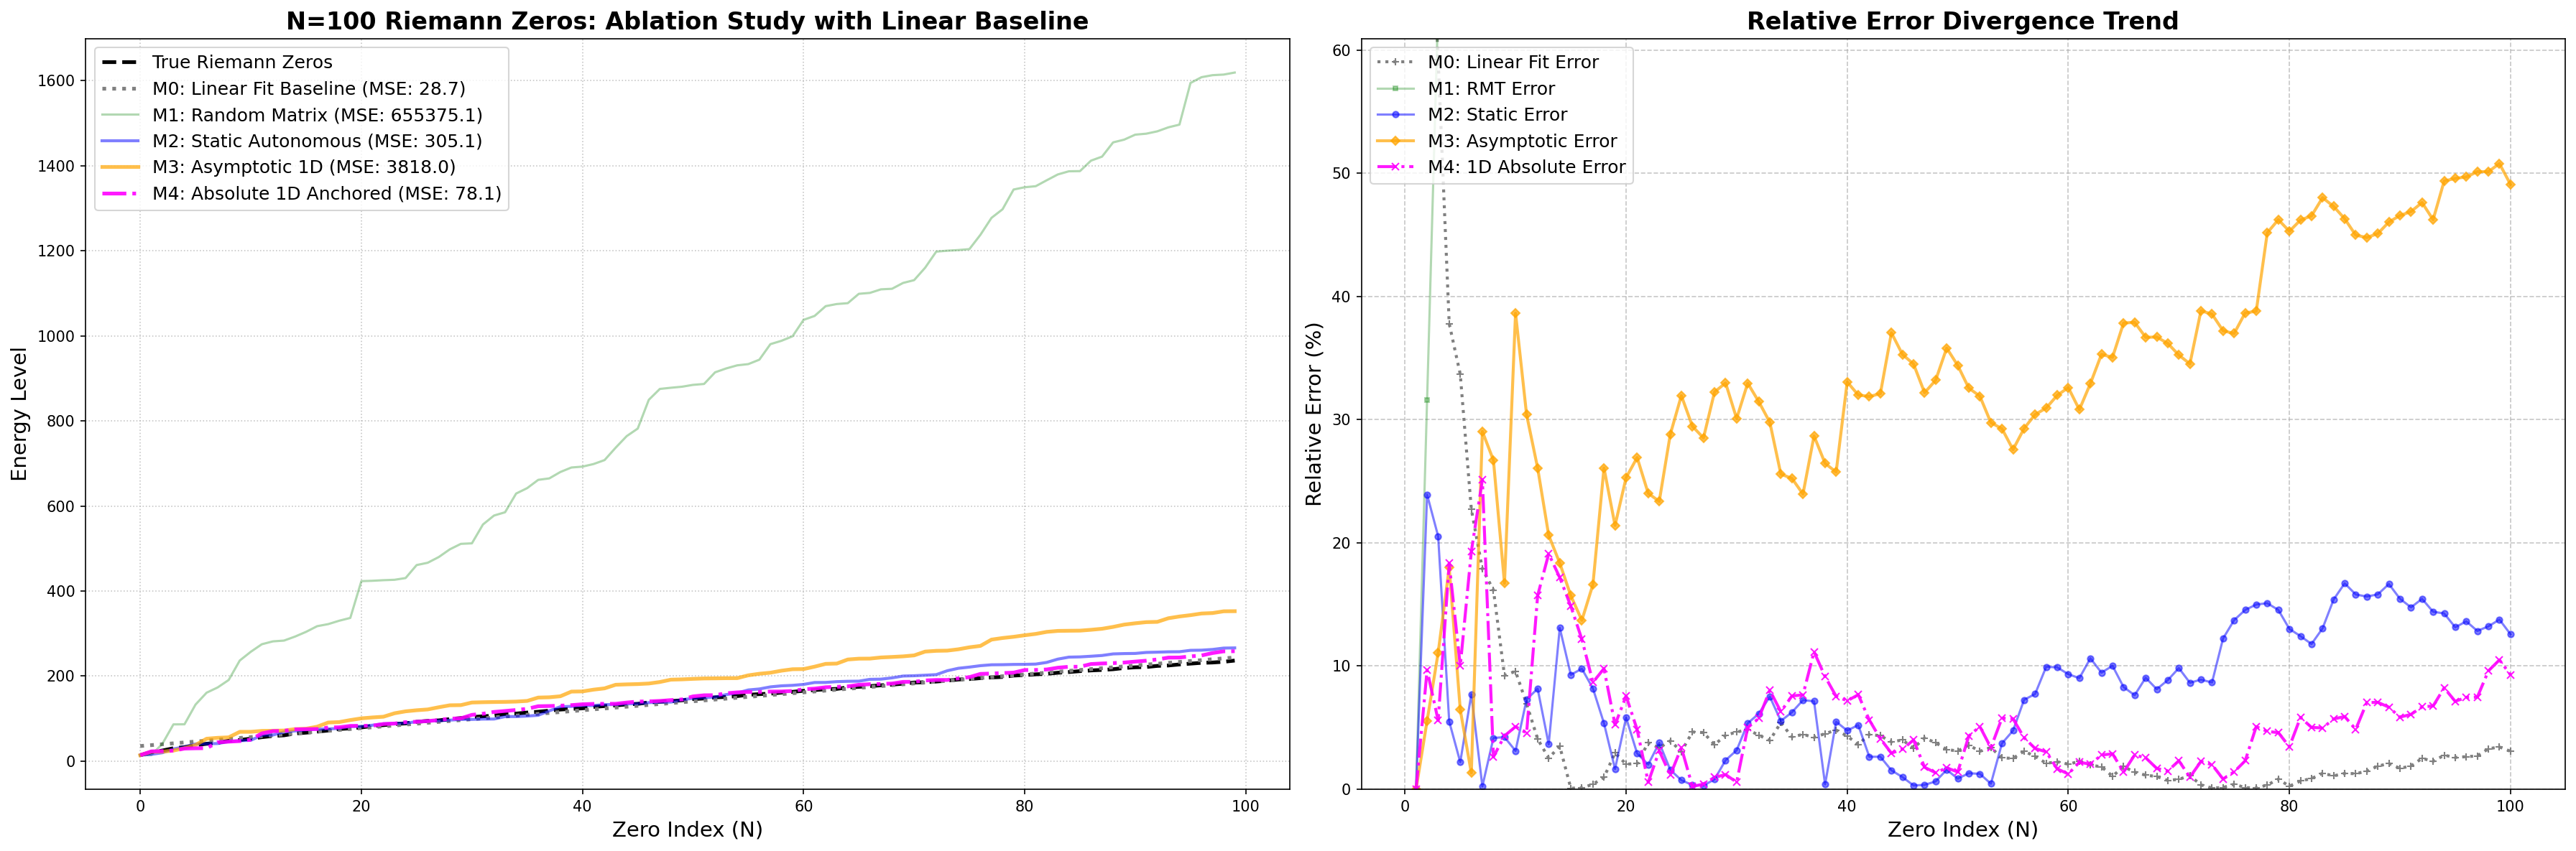


[+] 封神级六相消融图 (含 Linear Baseline) 已保存为 ultimate_ablation_with_linear_baseline.png！


<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
from numba import njit
import time

print("="*95)
print("🚀 史诗级六相消融：线性拟合 vs RMT vs 静态 vs 方法1 vs 方法2(1D) vs 方法5(2D)")
print("="*95)

# ================= 0. 准备真实的黎曼零点 (100个) =================
N_compare = 100
mpmath.mp.dps = 15
true_riemann_zeros = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_compare + 1)])
N_BINS = 2000  # 全场参数绝对统一

# ================= 0.5 直接线性拟合 (Linear Fitting Baseline) =================
print("[*] 正在计算 Model 0: 直接线性拟合 (Null Hypothesis Baseline)...")
n_indices = np.arange(1, N_compare + 1)
slope, intercept = np.polyfit(n_indices, true_riemann_zeros, 1)
calib_lin = slope * n_indices + intercept
err_lin = np.abs(calib_lin - true_riemann_zeros) / true_riemann_zeros * 100
mse_lin = np.mean((calib_lin - true_riemann_zeros)**2)
print(f"[M0: 直接线性拟合] Slope: {slope:.4f} | Intercept: {intercept:.4f} | MSE: {mse_lin:.2f} | 平均误差: {np.mean(err_lin):.2f}% | 最大误差: {np.max(err_lin):.2f}%")

# ================= 1. 完全随机矩阵 (Random Matrix) =================
print("[*] 正在计算 Model 1: 完全随机马尔可夫矩阵 (RMT)...")
np.random.seed(42)
random_matrix = np.random.rand(N_BINS, N_BINS)
row_sums_rnd = random_matrix.sum(axis=1, keepdims=True)
P_rnd = random_matrix / row_sums_rnd

eigenvalues_rnd, _ = np.linalg.eig(P_rnd)
valid_rnd = (eigenvalues_rnd.imag > 1e-5)
unwrapped_rnd = np.unwrap(np.sort(np.angle(eigenvalues_rnd[valid_rnd])))

# ================= 2. 逻辑映射 (Logistic Map, 静态自治)  精细化乌尔姆方法=================
print("[*] 正在计算 Model 2: 静态自治系统 (U_c=1.543689)...")
mu_static = 1.543689
POINTS_PER_BIN = 100
edges = np.linspace(-1, 1, N_BINS + 1)
transition_matrix_log = np.zeros((N_BINS, N_BINS))
for i in range(N_BINS):
    points = np.linspace(edges[i], edges[i+1], POINTS_PER_BIN, endpoint=False)
    mapped_points = np.clip(1 - mu_static * points**2, -0.999999, 0.999999)
    bin_indices = np.floor((mapped_points + 1) / 2 * N_BINS).astype(int)
    for j in bin_indices:
        transition_matrix_log[i, j] += 1

row_sums_log = transition_matrix_log.sum(axis=1, keepdims=True)
row_sums_log[row_sums_log == 0] = 1
P_log = transition_matrix_log / row_sums_log

eigenvalues_log, _ = np.linalg.eig(P_log)
valid_log = (eigenvalues_log.imag > 1e-5)
unwrapped_log = np.unwrap(np.sort(np.angle(eigenvalues_log[valid_log])))

# ================= 3. 动态非自治 (渐近截断 - 方法1) 蒙特卡洛方法=================
print("[*] 正在计算 Model 3: 渐近截断非自治系统 (Asymptotic Truncation)...")
@njit(fastmath=True, nogil=True)
def dynamic_asymptotic_kernel(u_c, k, steps, n_bins, offset):
    x = 0.5
    counts = np.zeros((n_bins, n_bins), dtype=np.float64)
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    for i in range(1000000):
        k_dyn = k / (np.log(i + offset)**2)
        x = 1.0 - (u_c + k_dyn) * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
    for i in range(1000000, steps + 1000000):
        k_dyn = k / (np.log(i + offset)**2)
        x = 1.0 - (u_c + k_dyn) * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
        
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        if 0 <= current_bin < n_bins and 0 <= last_bin < n_bins:
            counts[last_bin, current_bin] += 1
        last_bin = current_bin
    return counts

u_c_target = 1.543689
u_end_target = 1.5437  
steps_dyn1 = 20_000_000 
offset_dyn1 = 1000000.0 
k_safe = (u_end_target - u_c_target) * (np.log(offset_dyn1 + steps_dyn1)**2)

counts_dyn1 = dynamic_asymptotic_kernel(u_c_target, k_safe, steps_dyn1, N_BINS, offset_dyn1)
row_sums_dyn1 = counts_dyn1.sum(axis=1, keepdims=True)
row_sums_dyn1[row_sums_dyn1 == 0] = 1.0
P_dyn1 = counts_dyn1 / row_sums_dyn1

eigenvalues_dyn1, _ = np.linalg.eig(P_dyn1)
valid_dyn1 = (eigenvalues_dyn1.imag > 1e-5)
unwrapped_dyn1 = np.unwrap(np.sort(np.angle(eigenvalues_dyn1[valid_dyn1])))

# ================= 4. 动态非自治 (U_dyna 1D 边界锚定 - 方法2) 蒙特卡洛方法 =================
print("[*] 正在计算 Model 4: U_dyna 绝对边界锚定非自治系统 (1D)... 预计耗时1-2分钟")
@njit(fastmath=True, nogil=True)
def dynamic_anchored_1d_kernel(u_c, k_opt, steps, n_bins, offset):
    x = 0.5
    counts = np.zeros((n_bins, n_bins), dtype=np.float64)
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    t_end = 1.0 / (np.log(steps + offset)**2)
    u_temp = u_c - k_opt * t_end
    
    warmup_steps = 2000000 
    for i in range(warmup_steps):
        u_dyn = u_temp + k_opt / (np.log(i + offset)**2)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
    for i in range(warmup_steps, steps + warmup_steps):
        u_dyn = u_temp + k_opt / (np.log(i + offset)**2)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        if 0 <= current_bin < n_bins and 0 <= last_bin < n_bins: counts[last_bin, current_bin] += 1
        last_bin = current_bin
    return counts

# 🚀 还原绝对锚定的真实物理环境参数！
k_1d_best = 6.764850551029437
steps_dyn2 = 10_000_000_000  # 100 亿步！
offset_dyn2 = 100000.0
t1 = time.time()
counts_dyn2 = dynamic_anchored_1d_kernel(u_c_target, k_1d_best, steps_dyn2, N_BINS, offset_dyn2)
print(f"   -> Model 4 内核演化完成，耗时 {time.time()-t1:.1f} 秒")

row_sums_dyn2 = counts_dyn2.sum(axis=1, keepdims=True)
row_sums_dyn2[row_sums_dyn2 == 0] = 1.0
P_dyn2 = counts_dyn2 / row_sums_dyn2

eigenvalues_dyn2, _ = np.linalg.eig(P_dyn2)
valid_dyn2 = (eigenvalues_dyn2.imag > 1e-5)
unwrapped_dyn2 = np.unwrap(np.sort(np.angle(eigenvalues_dyn2[valid_dyn2])))

# ================= 5. 动态非自治 (U_dyna 2D 高阶绝对锚定 - 方法5) =================
print("[*] 正在计算 Model 5: U_dyna 2D 高阶绝对锚定 (Ultimate)... 预计耗时1-2分钟")
@njit(fastmath=True, nogil=True)
def dynamic_anchored_2d_kernel(u_c, k1, k2, steps, n_bins, offset):
    x = 0.5
    counts = np.zeros((n_bins, n_bins), dtype=np.float64)
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    L_end = np.log(steps + offset)
    u_temp = u_c - k1/(L_end**2) - k2/(L_end**3)
    
    warmup_steps = 2000000 
    for i in range(warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k1/(L_i**2) + k2/(L_i**3)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
    for i in range(warmup_steps, steps + warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k1/(L_i**2) + k2/(L_i**3)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        if 0 <= current_bin < n_bins and 0 <= last_bin < n_bins: counts[last_bin, current_bin] += 1
        last_bin = current_bin
    return counts

# 🚀 还原真实的物理圣杯环境参数！
k1_best = 7.351404
k2_best = 29.818054
steps_dyn3 = 10_000_000_000  # 100 亿步！
offset_dyn3 = 100000.0

t2 = time.time()
counts_dyn3 = dynamic_anchored_2d_kernel(u_c_target, k1_best, k2_best, steps_dyn3, N_BINS, offset_dyn3)
print(f"   -> Model 5 内核演化完成，耗时 {time.time()-t2:.1f} 秒")

row_sums_dyn3 = counts_dyn3.sum(axis=1, keepdims=True)
row_sums_dyn3[row_sums_dyn3 == 0] = 1.0
P_dyn3 = counts_dyn3 / row_sums_dyn3

eigenvalues_dyn3, _ = np.linalg.eig(P_dyn3)
valid_dyn3 = (eigenvalues_dyn3.imag > 1e-5)
unwrapped_dyn3 = np.unwrap(np.sort(np.angle(eigenvalues_dyn3[valid_dyn3])))

# ================= 6. 消融机制：纯比例缩放 (Pure Scaling) 包含 MSE =================
print("\n" + "="*80)
print("【处刑结果：仅锚定第1个零点进行纯缩放 (Scale Only) | 引入 MSE 审判】")

def apply_scaling(sim_phases, true_zeros, name):
    N_actual = min(len(sim_phases), len(true_zeros))
    sim = sim_phases[:N_actual]
    tz = true_zeros[:N_actual]
    
    scale = tz[0] / sim[0]
    calib = sim * scale
    
    # 计算相对误差和 MSE
    rel_err = np.abs(calib - tz) / tz * 100
    mse = np.mean((calib - tz)**2)
    
    print(f"[{name}] Scale: {scale:.4f} | 对齐: {N_actual} 阶 | MSE: {mse:.2f} | 平均误差: {np.mean(rel_err):.2f}% | 最大误差: {np.max(rel_err):.2f}%")
    
    pad_width = N_compare - N_actual
    full_calib = np.pad(calib, (0, pad_width), constant_values=np.nan)
    full_err = np.pad(rel_err, (0, pad_width), constant_values=np.nan)
    return full_calib, full_err, mse

calib_rnd, err_rnd, mse_rnd = apply_scaling(unwrapped_rnd, true_riemann_zeros, "M1: 完全随机 (RMT)")
calib_log, err_log, mse_log = apply_scaling(unwrapped_log, true_riemann_zeros, "M2: 静态自治 (Static)")
calib_dyn1, err_dyn1, mse_dyn1 = apply_scaling(unwrapped_dyn1, true_riemann_zeros, "M3: 渐近截断 (方法1)")
calib_dyn2, err_dyn2, mse_dyn2 = apply_scaling(unwrapped_dyn2, true_riemann_zeros, "M4: 1D 锚定 (方法2)")
#calib_dyn3, err_dyn3, mse_dyn3 = apply_scaling(unwrapped_dyn3, true_riemann_zeros, "M5: 2D 高阶锚定 (方法5)")

# ================= 7. 绘图对比 (将 MSE 直接打在公屏上) =================
fig, axes = plt.subplots(1, 2, figsize=(24, 8), dpi=150)

# 图 1：能级预测对比
axes[0].plot(true_riemann_zeros, 'k--', linewidth=2.5, label='True Riemann Zeros')
axes[0].plot(calib_lin, color='gray', linestyle=':', linewidth=2.5, label=f'M0: Linear Fit Baseline (MSE: {mse_lin:.1f})')
axes[0].plot(calib_rnd, 'g-', alpha=0.3, linewidth=1.5, label=f'M1: Random Matrix (MSE: {mse_rnd:.1f})')
axes[0].plot(calib_log, 'b-', alpha=0.5, linewidth=2.0, label=f'M2: Static Autonomous (MSE: {mse_log:.1f})')
axes[0].plot(calib_dyn1, color='orange', alpha=0.7, linewidth=2.5, label=f'M3: Asymptotic 1D (MSE: {mse_dyn1:.1f})')
axes[0].plot(calib_dyn2, color='magenta', alpha=0.9, linewidth=2.5, linestyle='-.', label=f'M4: Absolute 1D Anchored (MSE: {mse_dyn2:.1f})')
#axes[0].plot(calib_dyn3, 'r-', alpha=1.0, linewidth=3.5, label=f'M5: 2D Higher-Order (MSE: {mse_dyn3:.1f})')
axes[0].set_title("N=100 Riemann Zeros: Ablation Study with Linear Baseline", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Zero Index (N)", fontsize=14)
axes[0].set_ylabel("Energy Level", fontsize=14)
axes[0].legend(loc='upper left', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.7)

# 图 2：相对误差趋势对比
axes[1].plot(np.arange(1, N_compare + 1), err_lin, color='gray', linestyle=':', marker='+', markersize=5, linewidth=2, label='M0: Linear Fit Error')
axes[1].plot(np.arange(1, N_compare + 1), err_rnd, 'g-s', markersize=3, alpha=0.3, label='M1: RMT Error')
axes[1].plot(np.arange(1, N_compare + 1), err_log, 'b-o', markersize=4, alpha=0.5, label='M2: Static Error')
axes[1].plot(np.arange(1, N_compare + 1), err_dyn1, marker='D', color='orange', markersize=4, alpha=0.7, linewidth=2, label='M3: Asymptotic Error')
axes[1].plot(np.arange(1, N_compare + 1), err_dyn2, marker='x', color='magenta', markersize=5, alpha=0.9, linewidth=2, linestyle='-.', label='M4: 1D Absolute Error')
#axes[1].plot(np.arange(1, N_compare + 1), err_dyn3, 'r-^', markersize=6, alpha=1.0, linewidth=3.0, label='M5: 2D Ultimate Error')
axes[1].set_title("Relative Error Divergence Trend", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Zero Index (N)", fontsize=14)
axes[1].set_ylabel("Relative Error (%)", fontsize=14)
axes[1].legend(loc='upper left', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

axes[1].set_ylim(0, max(np.nanmax(err_dyn1)*1.2, 15)) 

plt.tight_layout()
plt.show()
plt.savefig("ultimate_ablation_with_linear_baseline.png")
print("\n[+] 封神级六相消融图 (含 Linear Baseline) 已保存为 ultimate_ablation_with_linear_baseline.png！")